# 03 — El producto end-to-end: del scraping a la dirección del dólar

Esta notebook recorre **todo el sistema, en orden y sin saltarse nada**:

| § | Etapa | Qué verás |
|---|---|---|
| 1 | **Scraping de noticias** (Bronze→Silver) | Los titulares crudos del día, sin LLM |
| 2 | **El movimiento de las monedas** | TRM oficial + Brent, DXY y bolsa colombiana |
| 3 | **GOLD: los topics y la golden query** | Cada noticia clasificada (topic, canal FX, severidad, entidades) y la consulta que filtra el oro del ruido |
| 4 | **El grafo de noticias** | Tópicos ↔ entidades con comunidades — los clusters del día |
| 5 | **El sistema multiagéntico** | QUÉ patrón es (la respuesta explícita) + el grafo LangGraph **renderizado** |
| 6 | **La corrida y la predicción** | El grafo completo ejecutándose → `DirectionalCall` |
| 7 | **Medición** | La tabla `predictions` que califica al sistema contra la realidad |

**El objetivo de estudio** (invariante desde el día 1): clasificar la **dirección** del
USD/COP — `down`/`up`/`neutral` — cruzando noticias analizadas por agentes con la señal
de la serie de tiempo, bajo una capa de racionalidad que obliga al contra-argumento y
acota la confianza por contrato.

---

### Actualizacion de producto: coherencia del adjudicador

El pipeline ya no confia solo en la prosa del LLM adjudicador. El juez debe declarar `dominant_signal` (`news`, `timeseries`, `market`, `none`) y el codigo valida que la direccion final coincida con esa senal. Si el racional dice que domina una noticia fiscal pero la direccion emitida apunta al lado contrario, el sistema corrige la direccion, baja/confina la confianza y deja el motivo en `consistency_notes`.

Los prompts tambien fueron endurecidos: cada agente debe trabajar como analista independiente, rechazar ruido, distinguir sorpresa de repeticion, nombrar canal de transmision FX y explicar por que una senal pierde contra otra.

In [1]:
# Setup — limpio: sin os.chdir, sin adivinar rutas con cwd.
# cop_fx.paths resuelve la raíz desde el paquete y Settings lee el .env absoluto.
import sys

try:
    import cop_fx  # noqa: F401
except ModuleNotFoundError:
    raise RuntimeError(
        f"KERNEL EQUIVOCADO ({sys.executable}).\n"
        "En VS Code: selector de kernel → 'Python (cop-fx-intelligence)'."
    ) from None

from cop_fx.config.settings import get_settings
from cop_fx.paths import DATA_DIR, PROJECT_ROOT

settings = get_settings()
assert settings.openai_api_key is not None, f"Falta OPENAI_API_KEY en {PROJECT_ROOT / '.env'}"

print(f"✓ Proyecto : {PROJECT_ROOT.name}")
print(f"✓ LLM      : {settings.llm_model} ({settings.llm_provider})")
print(f"✓ Datos    : {DATA_DIR}")

✓ Proyecto : cop-fx-intelligence
✓ LLM      : gpt-5-mini (openai)
✓ Datos    : /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/data


## 1. Scraping de noticias — Bronze → Silver

Determinista y aburrido a propósito: feeds RSS de economía colombiana, CNN Colombia
(HTML de respaldo) y los feeds macro del lado USD (CNBC, MarketWatch). Cero LLM.
El resultado es `list[Article]` — el Silver que alimenta a los agentes.

In [2]:
import pandas as pd

from cop_fx.data.news_fetcher import NewsFetcher

articles = NewsFetcher().fetch()
df_silver = pd.DataFrame(
    {
        "fecha": [a.published_at.strftime("%Y-%m-%d") for a in articles],
        "fuente": [a.source[:24] for a in articles],
        "titular": [a.title for a in articles],
    }
)
print(f"✓ {len(articles)} artículos SILVER — ⚠ esta tabla muestra SOLO titulares")
print("  (así llega el crudo; el TEXTO COMPLETO se descarga y analiza en la sección 3)")
print("  Orden: por FECHA con fuentes intercaladas — mismo día = mismo pie.\n")
df_silver.head(15)

22:04:42  INFO      cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: inicio (max=100)


22:04:43  SUCCESS   cop_fx.data.http  —  HTTP 200 · 3497464 bytes · https://cnnespanol.cnn.com/colombia/


22:04:43  SUCCESS   cop_fx.data.cnn_fetcher  —  HTML: 23 artículos de 43 tarjetas


22:04:44  WARNING   cop_fx.data.cnn_fetcher  —  RSS sin entradas (probable 404): https://cnnespanol.cnn.com/colombia/feed/


22:04:44  WARNING   cop_fx.data.cnn_fetcher  —  RSS sin entradas (probable 404): https://cnnespanol.cnn.com/feed/


22:04:44  SUCCESS   cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: 23 únicos | con autor: 0/23


22:04:44  SUCCESS   cop_fx.data.news_fetcher  —  Fetched 100 unique articles total


✓ 100 artículos SILVER — ⚠ esta tabla muestra SOLO titulares
  (así llega el crudo; el TEXTO COMPLETO se descarga y analiza en la sección 3)
  Orden: por FECHA con fuentes intercaladas — mismo día = mismo pie.



,fecha,fuente,titular
0,2026-06-25,La República - Economía,Carlos Fernando Galán confirmó que enviarán ay...
1,2026-06-25,PORTAFOLIO.CO -Economía,Corte Constitucional revivió emergencia económ...
2,2026-06-25,La República - Economía,Minhacienda hizo colocación de TES en pesos po...
3,2026-06-25,PORTAFOLIO.CO -Economía,Bogotá enviará ayuda a Venezuela tras terremot...
4,2026-06-24,La República - Economía,JPMorgan planteó la tesis T.I.G.R.E tras elecc...
5,2026-06-24,PORTAFOLIO.CO -Economía,Banco de Bogotá colocó bonos ordinarios por $2...
6,2026-06-24,CNN Español Colombia,Declaran a Abelardo de la Espriella ganador de...
7,2026-06-24,La República - Economía,Entre 2018 y 2025 las reservas probadas de gas...
8,2026-06-24,PORTAFOLIO.CO -Economía,Felipe Harman regresará a la Agencia Nacional ...
9,2026-06-24,CNN Español Colombia,Gobernar Colombia será realmente difícil para ...


## 2. El movimiento de las monedas

La TRM oficial (datos.gov.co) más el contexto de mercado que el estudio de la
notebook 02 validó: Brent, DXY y la bolsa colombiana (GXG) — recuerda que el equity
de ayer es el único predictor adelantado que pasó el filtro lead-lag.

22:04:45  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


22:04:45  INFO      cop_fx.data.fx_fetcher  —  Fetched 235 FX rows (start=2025-06-24, end=2026-06-24)


22:04:46  INFO      cop_fx.data.market_fetcher  —  Serie brent (BZ=F): 301 filas


22:04:46  INFO      cop_fx.data.market_fetcher  —  Serie dxy (DX-Y.NYB): 302 filas


22:04:47  INFO      cop_fx.data.market_fetcher  —  Serie equity (GXG): 361 filas


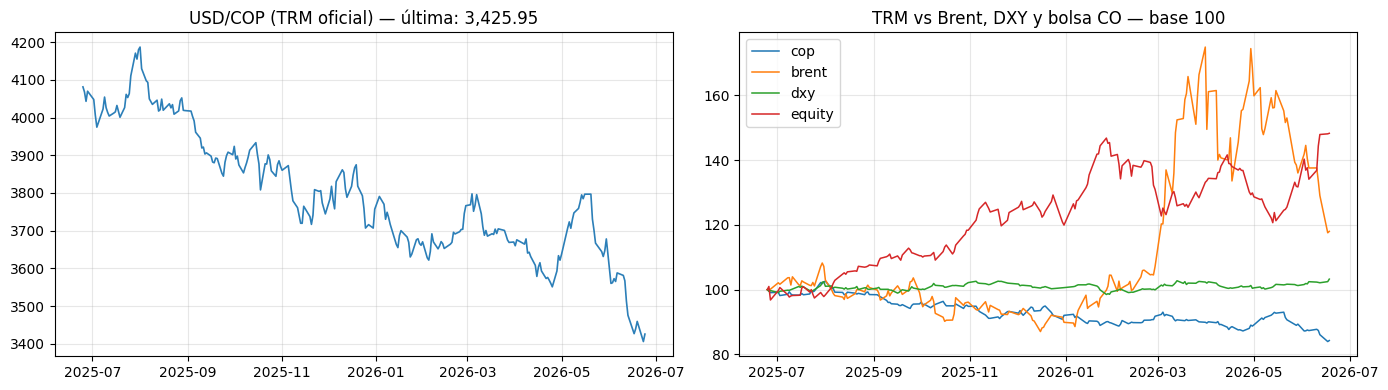

In [3]:
import matplotlib.pyplot as plt

from cop_fx.data.fx_fetcher import FXFetcher
from cop_fx.data.market_fetcher import fetch_market_panel

fx = FXFetcher().fetch()
panel = fetch_market_panel(fx)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(fx["ds"], fx["y"], color="#2c7fb8", lw=1.2)
axes[0].set_title(f"USD/COP (TRM oficial) — última: {fx['y'].iloc[-1]:,.2f}")
axes[0].grid(alpha=0.3)
for col in [c for c in panel.columns if c != "ds"]:
    axes[1].plot(panel["ds"], 100 * panel[col] / panel[col].iloc[0], label=col, lw=1.1)
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("TRM vs Brent, DXY y bolsa CO — base 100")
plt.tight_layout(); plt.show()

## 3. GOLD — los topics y la *golden query*

Aquí el LLM toca el dato por primera vez. El `NewsAnalyzer` (el mismo del pipeline)
clasifica cada artículo con la **taxonomía de dos niveles**:

- `topic`: qué ES la noticia (15 dominios: `political_risk`, `monetary_policy`,
  `public_health`, `environment_climate`, `sports`...)
- `fx_relevance` + `fx_channel`: si transmite al dólar y POR QUÉ mecanismo —
  con coherencia forzada por contrato (deportes ⇒ relevancia `none` ⇒ pesa 0).

In [4]:
from cop_fx.analysis.news_analyzer import NewsAnalyzer
from cop_fx.config.settings import get_settings
from cop_fx.data.article_body import attach_bodies

# Selección GOLD — en el ORDEN del fetcher (fecha + fuentes intercaladas):
# se descarga el texto completo y se FILTRA lo que no tiene texto analizable.
# NO se reordena por longitud: extraíble ≠ relevante (la reforma tributaria
# de Portafolio vale aunque su paywall solo deje una línea de resumen).
cfg = get_settings()
pool = articles[:100]
attach_bodies(pool, max_articles=100)

def _text_len(a):
    return len(getattr(a, "body", "") or a.summary)

subset = [a for a in pool if _text_len(a) >= cfg.min_analyzable_chars][:20]
print(f"Pool {len(pool)} → descartados {len(pool) - sum(1 for a in pool if _text_len(a) >= cfg.min_analyzable_chars)} sin texto → analizamos {len(subset)}")

analysis = NewsAnalyzer().analyze(subset)

pd.set_option("display.max_colwidth", 90)
df_gold = pd.DataFrame([
    {
        "titular": it.article.title[:55],
        "autor": getattr(it.article, "author", "") or "(sin autor)",
        "fuente": it.article.source[:14],
        "noticia": ((getattr(it.article, "body", "") or it.article.summary)[:85] + "…"),
        "chars_texto": _text_len(it.article),
        "topic": it.topic,
        "fx_relevance": it.fx_relevance,
        "fx_channel": it.fx_channel,
        "severity": it.severity,
        "bullish_cop": it.bullish_cop,
    }
    for it in analysis.items
])
print(f"✓ {len(df_gold)} GOLD · fuentes: {sorted(df_gold['fuente'].unique())} · "
      f"texto medio {df_gold['chars_texto'].mean():,.0f} chars\n")
print(f"Narrativa del día:\n{analysis.narrative}\n")
df_gold

22:04:49  SUCCESS   cop_fx.data.http  —  HTTP 200 · 81294 bytes · https://www.larepublica.co/economia/carlos-fernando-galan-confirmo-que-enviaran-ayudas-a-venezuela-tras-temblor-4422709


22:04:49  SUCCESS   cop_fx.data.http  —  HTTP 200 · 131405 bytes · https://www.portafolio.co/economia/gobierno/corte-constitucional-revivio-emergencia-economica-con-la-que-da-viabilidad-al-impuesto-al-patrimonio-para-juridicos-496894


22:04:49  WARNING   cop_fx.data.article_body  —  Cuerpo demasiado corto (241 chars) en https://www.portafolio.co/economia/gobierno/corte-constitucional-revivio-emergencia-economica-con-la-que-da-viabilidad-al-impuesto-al-patrimonio-para-juridicos-496894 — probable paywall/boilerplate


22:04:49  SUCCESS   cop_fx.data.http  —  HTTP 200 · 81857 bytes · https://www.larepublica.co/economia/minhacienda-hizo-colocacion-de-tes-en-pesos-por-casi-5-billones-con-tasas-superiores-a-12-4422412


22:04:50  SUCCESS   cop_fx.data.http  —  HTTP 200 · 131301 bytes · https://www.portafolio.co/economia/regiones/bogota-enviara-ayuda-a-venezuela-tras-terremoto-que-afecto-al-pais-vecino-496892


...

22:05:17  SUCCESS   cop_fx.data.http  —  HTTP 200 · 808855 bytes · https://www.cnbc.com/2026/06/17/iranian-tankers-oil-shipment-us-iran-deal-strait-of-hormuz-.html


22:05:17  INFO      cop_fx.data.article_body  —  Cuerpos descargados: 87/100 artículos


Pool 100 → descartados 5 sin texto → analizamos 20


✓ 20 GOLD · fuentes: ['CNN Español Co', 'La República -', 'PORTAFOLIO.CO '] · texto medio 1,826 chars

Narrativa del día:
La noticia dominante es política: la confirmación y ratificación de Abelardo de la Espriella eleva el canal de country risk como fuerza principal sobre USD/COP. En paralelo, factores domésticos de política monetaria (expectativas de subidas de BanRep y discusión sobre estanflación) y señales sobre deuda local (subasta de TES) controlan el canal de tasas y flujos de capital; tensiones entre mayor riesgo político y mayores tasas son el conflicto central. La evidencia de hoy es lo bastante fuerte como para generar volatilidad temporal en el tipo de cambio, pero no invalida automáticamente un sesgo estadístico si los mercados descuentan rápidamente medidas de gobernabilidad y respuesta de política monetaria.



,titular,autor,fuente,noticia,chars_texto,topic,fx_relevance,fx_channel,severity,bullish_cop
0,Carlos Fernando Galán confirmó que enviarán ayudas a Ve,(sin autor),La República -,"Carlos Fernando Galán , alcalde de Bogotá, aseguró que Bogotá enviará ayudas a Venezu…",1449,other,none,none,low,False
1,Corte Constitucional revivió emergencia económica con l,(sin autor),PORTAFOLIO.CO,Esta se había declarado inexequible en abril de este año por parte del alto tribunal.…,85,fiscal_policy,indirect,capital_flows,low,False
2,Minhacienda hizo colocación de TES en pesos por casi $5,(sin autor),La República -,El Ministerio de Hacienda colocó este 24 de junio un monto de casi $5 billones en la …,1252,financial_markets,direct,interest_rates,low,True
3,JPMorgan planteó la tesis T.I.G.R.E tras elecciones pre,(sin autor),La República -,JPmorgan presentó la tesis T.I.G.R.E. para Colombia tras realizarse la segunda vuelta…,2028,financial_markets,indirect,capital_flows,low,True
4,Banco de Bogotá colocó bonos ordinarios por $250.000 mi,(sin autor),PORTAFOLIO.CO,La operación corresponde al primer lote de la segunda emisión y la demanda llegó hast…,109,financial_markets,none,none,low,False
5,Declaran a Abelardo de la Espriella ganador de las elec,(sin autor),CNN Español Co,El candidato ultraderechista Abelardo de la Espriella fue declarado ganador de la ele…,2324,political_risk,direct,country_risk,high,False
6,Entre 2018 y 2025 las reservas probadas de gas de Colom,(sin autor),La República -,"El informe de reservas presentado por la Agencia Nacional de Hidrocarburos, ANH , sem…",2078,energy_commodities,indirect,terms_of_trade,medium,False
7,Felipe Harman regresará a la Agencia Nacional de Tierra,(sin autor),PORTAFOLIO.CO,El hoy exdirector alertó por una posible recuperación de bienes campesinos por parte …,97,other,none,none,low,False
8,Gobernar Colombia será realmente difícil para Abelardo,(sin autor),CNN Español Co,"La ajustada victoria que consiguió Abelardo de la Espriella en Colombia, la segunda v…",3500,political_risk,indirect,country_risk,low,False
9,La Corte Constitucional avaló emergencia económica decl,(sin autor),La República -,"La Corte Constitucional declaró la constitucionalidad, de manera condicionada, del De…",3500,fiscal_policy,indirect,growth,low,False


In [5]:
# EVIDENCIA — esto es literalmente lo que lee el agente (no el titular):
for a in subset[:3]:
    text = (getattr(a, "body", "") or a.summary)[:350]
    print(f"━━ [{a.source[:20]}] {a.title[:70]}")
    print(f"   TEXTO ({_text_len(a)} chars): «{text}…»\n")

━━ [La República - Econo] Carlos Fernando Galán confirmó que enviarán ayudas a Venezuela tras te
   TEXTO (1449 chars): «Carlos Fernando Galán , alcalde de Bogotá, aseguró que Bogotá enviará ayudas a Venezuela tras el sismo presentado en el vecino país. "Venezuela nos necesita y en Bogotá estamos listos para ayudar", aseguró en su cuenta de X .
Según afirmó Galán, ya se dio la instrucción al Instituto Distrital de Gestión de Riesgos y Cambio Climático, Idiger , para …»

━━ [PORTAFOLIO.CO -Econo] Corte Constitucional revivió emergencia económica con la que da viabil
   TEXTO (85 chars): «Esta se había declarado inexequible en abril de este año por parte del alto tribunal.…»

━━ [La República - Econo] Minhacienda hizo colocación de TES en pesos por casi $5 billones con t
   TEXTO (1252 chars): «El Ministerio de Hacienda colocó este 24 de junio un monto de casi $5 billones en la subasta número 11 del año denominada en Títulos de Tesorería denominados en pesos. La operación incluyó referen

In [6]:
# LA GOLDEN QUERY: separar el oro del ruido.
# De todo lo scrapeado, ¿qué tiene canal de transmisión al dólar y con qué fuerza?
golden = (
    df_gold[df_gold["fx_relevance"] != "none"]
    .sort_values("severity", key=lambda s: s.map({"high": 0, "medium": 1, "low": 2}))
    .reset_index(drop=True)
)
print(f"Golden query: {len(golden)} de {len(df_gold)} artículos tienen señal FX\n")
display(golden)

print("\nTopic × relevancia FX — cuánto del día es señal vs ruido:")
pd.crosstab(df_gold["topic"], df_gold["fx_relevance"])

Golden query: 14 de 20 artículos tienen señal FX



,titular,autor,fuente,noticia,chars_texto,topic,fx_relevance,fx_channel,severity,bullish_cop
0,Declaran a Abelardo de la Espriella ganador de las elec,(sin autor),CNN Español Co,El candidato ultraderechista Abelardo de la Espriella fue declarado ganador de la ele…,2324,political_risk,direct,country_risk,high,False
1,Entre 2018 y 2025 las reservas probadas de gas de Colom,(sin autor),La República -,"El informe de reservas presentado por la Agencia Nacional de Hidrocarburos, ANH , sem…",2078,energy_commodities,indirect,terms_of_trade,medium,False
2,"Abelardo De La Espriella, presidente electo de Colombia",(sin autor),PORTAFOLIO.CO,Resultados oficiales del CNE dan 12'960.166 votos a De La Espriella y 12'708.312 a Ce…,90,political_risk,direct,country_risk,medium,False
3,¿Qué tan cerca estaría Colombia de una estanflación?: e,(sin autor),PORTAFOLIO.CO,"En mayo de este año, la inflación anual llegó a 5,84% y el crecimiento en el primer t…",106,monetary_policy,indirect,interest_rates,medium,False
4,Analistas encuestados por Anif apuestan a que el Emisor,(sin autor),La República -,Anif publicó los resultados de la encuesta que realiza entre analistas sobre la tasa …,3500,monetary_policy,direct,interest_rates,medium,True
5,Más de 120 productos serían tocados con aranceles 'inte,(sin autor),La República -,"Higiene personal, ropa de cama, colchones, artículos de cocina y otros productos pres…",3500,trade,indirect,terms_of_trade,medium,True
6,Corte Constitucional revivió emergencia económica con l,(sin autor),PORTAFOLIO.CO,Esta se había declarado inexequible en abril de este año por parte del alto tribunal.…,85,fiscal_policy,indirect,capital_flows,low,False
7,Minhacienda hizo colocación de TES en pesos por casi $5,(sin autor),La República -,El Ministerio de Hacienda colocó este 24 de junio un monto de casi $5 billones en la …,1252,financial_markets,direct,interest_rates,low,True
8,JPMorgan planteó la tesis T.I.G.R.E tras elecciones pre,(sin autor),La República -,JPmorgan presentó la tesis T.I.G.R.E. para Colombia tras realizarse la segunda vuelta…,2028,financial_markets,indirect,capital_flows,low,True
9,Gobernar Colombia será realmente difícil para Abelardo,(sin autor),CNN Español Co,"La ajustada victoria que consiguió Abelardo de la Espriella en Colombia, la segunda v…",3500,political_risk,indirect,country_risk,low,False



Topic × relevancia FX — cuánto del día es señal vs ruido:


fx_relevance,direct,indirect,none
topic,,,
energy_commodities,0,1,0
financial_markets,1,2,1
fiscal_policy,0,2,0
labor_social,0,0,1
monetary_policy,1,1,0
other,0,0,3
political_risk,2,3,1
trade,0,1,0


## Keywords, entidades y taxonomía normalizada

La capa GOLD no solo clasifica `topic`, `fx_channel` y severidad. También extrae `keywords` y `entities`, que sirven para auditar qué conceptos están dominando la señal noticiosa. En producto, el dashboard pondera estas palabras por importancia (`severity x relevance + canal`) para evitar que una palabra repetida en noticias de baja relevancia parezca más importante que un shock material.

La normalización de topics vive en `cop_fx.analysis.topic_taxonomy`: agrupa dominios finos en familias de decisión (`Riesgo pais`, `Riesgo fiscal`, `Commodities`, etc.) y marca huecos de investigación cuando una noticia material cae en `other`, no tiene canal FX, o parece un falso positivo.


In [7]:
from cop_fx.analysis.topic_taxonomy import article_importance, normalize_topic

if "df" in globals() and {"topic", "keywords", "fx_relevance", "fx_channel", "severity"}.issubset(df.columns):
    df_keywords = df.copy()
    df_keywords["topic_family"] = df_keywords["topic"].apply(normalize_topic)
    df_keywords["importance"] = df_keywords.apply(article_importance, axis=1)
    display(df_keywords[["title", "topic_family", "keywords", "entities", "importance"]].head(20))
else:
    print("Ejecuta primero la celda que construye df GOLD para ver keywords ponderadas.")


Ejecuta primero la celda que construye df GOLD para ver keywords ponderadas.


## 4. El grafo de noticias — tópicos ↔ entidades

Tu idea original del proyecto: ver cómo interactúan los temas del día. Grafo bipartito
(tópicos ↔ entidades nombradas), aristas ponderadas por co-mención, **comunidades**
detectadas por modularidad. Cada comunidad es un cluster temático — exactamente la
unidad de trabajo que el orchestrator despacha con `Send` en la sección siguiente.

33 nodos · 25 aristas · 8 comunidades · puentes entre tópicos: ninguno


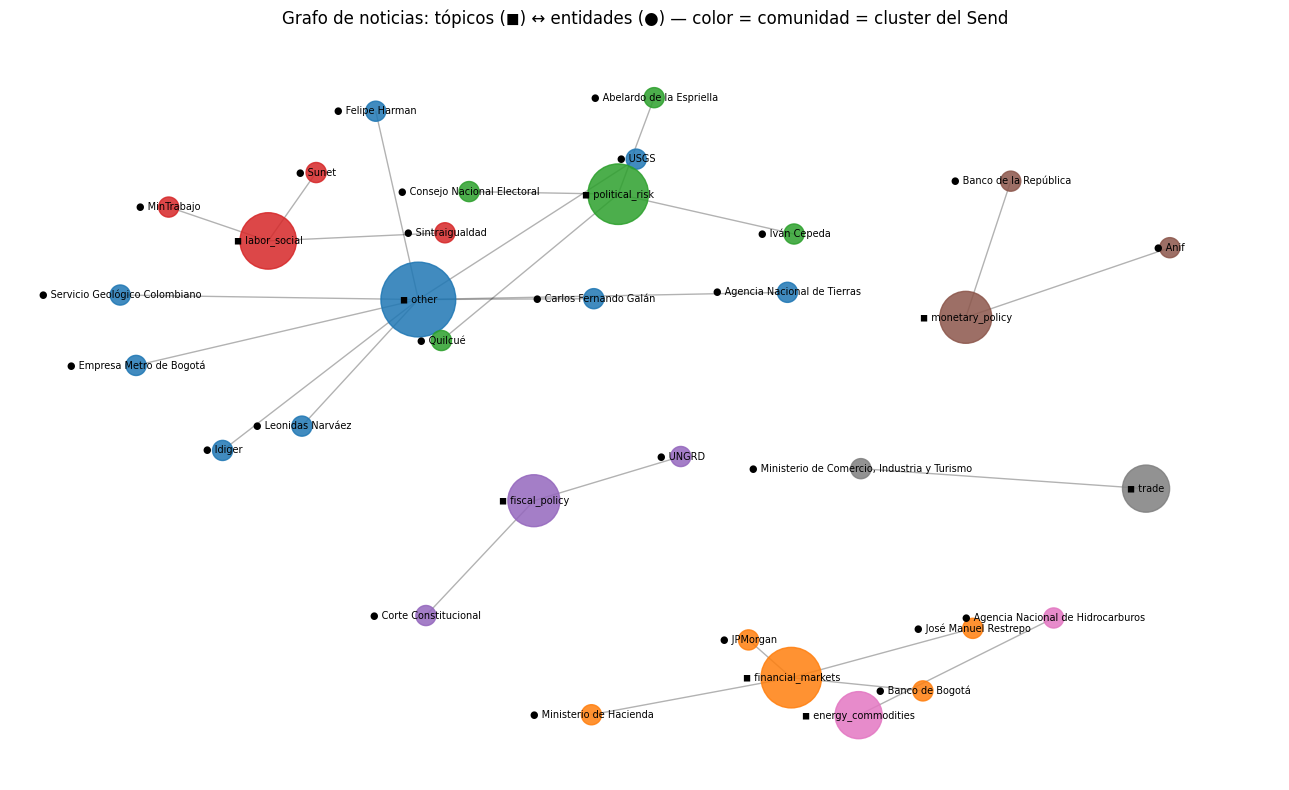

In [8]:
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

G = nx.Graph()
for it in analysis.items:
    t = f"◼ {it.topic}"
    G.add_node(t, kind="topic")
    for e in it.entities:
        en = f"● {e}"
        G.add_node(en, kind="entity")
        w = (G.get_edge_data(t, en) or {}).get("weight", 0)
        G.add_edge(t, en, weight=w + 1)

communities = list(greedy_modularity_communities(G, weight="weight"))
bridges = [n for n in G.nodes if G.nodes[n]["kind"] == "entity"
           and len({nb for nb in G.neighbors(n) if G.nodes[nb]["kind"] == "topic"}) > 1]
print(f"{G.number_of_nodes()} nodos · {G.number_of_edges()} aristas · "
      f"{len(communities)} comunidades · puentes entre tópicos: {bridges or 'ninguno'}")

fig, ax = plt.subplots(figsize=(13, 8))
pos = nx.spring_layout(G, k=0.65, seed=42, weight="weight")
palette = plt.colormaps["tab10"].colors
colors = [palette[next(ci for ci, c in enumerate(communities) if n in c) % 10] for n in G.nodes]
sizes = [900 + 250 * int(G.degree(n)) if G.nodes[n]["kind"] == "topic"
         else 120 + 90 * int(G.degree(n)) for n in G.nodes]
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
ax.set_title("Grafo de noticias: tópicos (◼) ↔ entidades (●) — color = comunidad = cluster del Send")
ax.axis("off"); plt.tight_layout(); plt.show()

## 5. El sistema multiagéntico — la respuesta explícita: ¿qué patrón es?

**No es UN patrón: es una composición de seis, cada uno resolviendo un problema
distinto.** El dominante es **orchestrator-workers + evaluator**; los demás son capas
de soporte. Este era el dilema original del proyecto ("¿prompt chaining, routing,
parallelization u orchestrator-worker?") y esta es la respuesta final:

| Patrón | Nodo(s) en este sistema | Qué problema resuelve |
|---|---|---|
| **Parallelization** | `fetch_fx` ‖ `fetch_market` ‖ `fetch_news` desde START; los N workers en un mismo superstep | Las señales son independientes: descargarlas y analizarlas a la vez |
| **Routing** | `check_materiality` → `add_conditional_edges` → `orchestrate` o `skip_news` | Control de costo: un día sin noticia material no gasta tokens de análisis |
| **Orchestrator-workers** (API `Send`) | `orchestrate` → `Send("topic_worker", cluster)` × N → reducers `operator.add` | La cantidad de analistas la decide el DATO (los clusters del §4), no el código — un grafo estático no puede |
| **Prompt chaining** | dentro de cada `topic_worker`: extraer → clasificar → canal de transmisión → impacto | Sub-pasos secuenciales de razonamiento por cluster |
| **Evaluator / racionalidad** | `adjudicate` (`defer=True`, tier judge) | Reconcilia noticias vs serie vs contexto de mercado; abogado del diablo obligatorio; confianza ACOTADA por validadores Pydantic, no por el prompt |
| **Persistencia + HITL + memoria** | `human_review` (`interrupt`) · `load_memory` · `SqliteSaver` por `thread_id` | Pausa para revisión humana del veredicto y reanuda en otro proceso; el adjudicador recuerda su track-record entre corridas |

**Las dos reglas de oro del diseño:**
1. El LLM solo razona sobre TEXTO; todos los NÚMEROS (señales, pesos, confianza,
   evaluación) los produce código determinista. El modelo no puede inventarse un score.
2. Un nodo nuevo solo entra si toma una decisión que un nodo determinista no podía
   tomar — el multiagente se gana con necesidad, no con ambición.

## Etapa 6 — las dos memorias de LangGraph + human-in-the-loop

El grafo usa los dos tipos de memoria que LangGraph distingue, más un `interrupt`:

- **Checkpointer (memoria de corto plazo, por `thread_id`)**: `SqliteSaver` guarda
  el estado del grafo paso a paso. Es lo que habilita **pausar y reanudar en otro
  proceso**. Sin checkpointer no hay dónde "congelar" la corrida.
- **Store (memoria de largo plazo, entre hilos)**: un almacén
  `namespace → key → value`. El nodo `load_memory` publica ahí el track-record; la
  fuente durable real es `predictions.db`.
- **`interrupt` (HITL)**: el nodo `human_review` lanza `interrupt(payload)` antes de
  finalizar; el grafo se pausa y devuelve el veredicto del día. Se reanuda con
  `Command(resume={"approved": bool})` sobre el mismo `thread_id` — **sin recomputar
  el LLM**, porque el checkpointer restaura el estado.

La **memoria entre corridas** cierra el loop de aprendizaje: el adjudicador lee qué
llamó antes y si acertó, y se calibra ("tus últimas llamadas de alta confianza
fallaron — exige más evidencia") en vez de empezar de cero cada día. `load_memory`
corre como rama paralela SIN arista al adjudicador, igual que `fetch_market`: escribe
estado que el nodo `defer=True` espera, sin sumar un trigger que lo dispararía dos veces.

```bash
uv run cop-fx run --review                      # corre y PAUSA pidiendo revisión
uv run cop-fx resume --thread <fecha> --approve # reanuda y acepta el veredicto
```

Importing plotly failed. Interactive plots will not work.


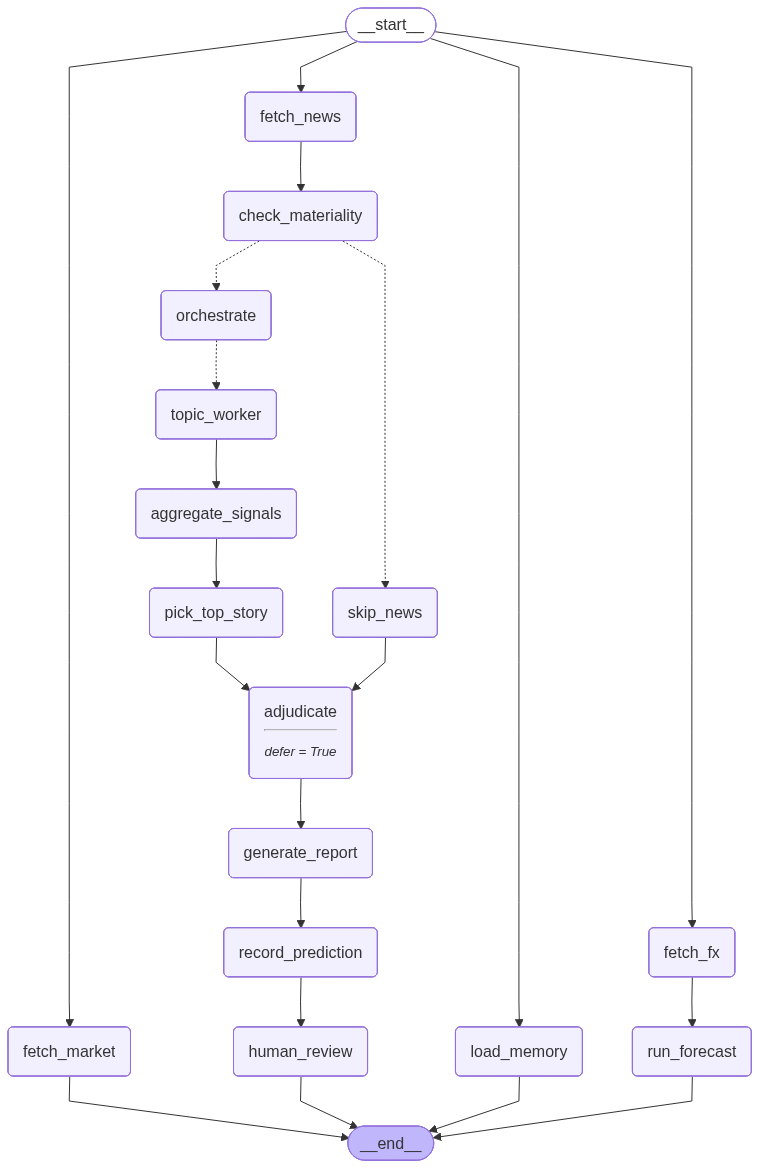

In [9]:
# El grafo LangGraph, RENDERIZADO (no texto): éste es el sistema completo
from IPython.display import Image, display

from cop_fx.agents.graph import build_graph

compiled = build_graph().compile()
try:
    display(Image(compiled.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(f"(render remoto no disponible: {exc} — versión texto)\n")
    print(compiled.get_graph().draw_mermaid())

## 6. La corrida completa → la predicción de la dirección

Todo lo anterior, orquestado en una sola invocación — lo mismo que ejecuta
`uv run cop-fx run` cada día.

In [10]:
from cop_fx.agents.graph import run_pipeline

final_state = run_pipeline()

print("\n=== resumen de la corrida ===")
print(f"TRM            : {final_state.get('latest_rate', 0):,.2f} ({final_state.get('rate_change_pct', 0):+.2f}% 30d)")
print(f"Mercado (ayer) : {final_state.get('market_signal', {})}")
print(f"¿Día material? : {final_state.get('has_material_news')}")
print(f"Clusters (Send): { {t: len(i) for t, i in final_state.get('clusters', {}).items()} }")
print(f"Errores        : {final_state.get('errors', [])}")

22:06:13  INFO      cop_fx.agents.nodes  —  Memoria: 1 llamadas evaluadas, acierto 0.0


22:06:13  INFO      cop_fx.data.fx_fetcher  —  FX source: TRM datos.gov.co


22:06:13  INFO      cop_fx.data.fx_fetcher  —  Fetched 235 FX rows (start=2025-06-24, end=2026-06-24)


22:06:14  INFO      cop_fx.data.cnn_fetcher  —  CNNColombiaFetcher: inicio (max=100)


22:06:14  INFO      cop_fx.agents.nodes  —  Market context: neutral (equity +0.11%, dxy -0.07%, brent -1.52%)


...

22:08:41  INFO      cop_fx.analysis.gold_store  —  Persisted GOLD keyword insights to /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/data/cnn_articles.db


22:09:00  INFO      cop_fx.agents.nodes  —  Top story: Declaran a Abelardo de la Espriella ganador de las elecciones presidenciales en Colombia (CNN Español Colombia)


22:09:08  INFO      cop_fx.agents.nodes  —  DirectionalCall: down (confianza=0.54, reconciliación=agree)


22:09:08  INFO      cop_fx.tracking.predictions  —  Prediction saved: 2026-06-24 → down (0.54)



=== resumen de la corrida ===
TRM            : 3,425.95 (-7.57% 30d)
Mercado (ayer) : {'direction': 'neutral', 'equity_ret_1d_pct': 0.114, 'dxy_ret_1d_pct': -0.075, 'brent_ret_1d_pct': -1.519}
¿Día material? : True
Clusters (Send): {'fiscal_policy': 4, 'energy_commodities': 4, 'political_risk': 3, 'financial_markets': 3, 'trade': 2, 'other': 2}
Errores        : []


In [11]:
call = final_state["directional_call"]
ARROW = {"down": "⬇️ USD/COP BAJA (COP se fortalece)",
         "up": "⬆️ USD/COP SUBE (COP se debilita)",
         "neutral": "⏸️ NEUTRAL — abstención"}

print("=" * 70)
print(f"  {ARROW[call['direction']]}")
print(f"  confianza {call['confidence']:.2f} · horizonte {call['horizon_days']}d · reconciliación: {call['reconciliation']}")
print("=" * 70)
print(f"  noticias : {call['news_signal']['direction']} (score {call['news_signal']['score']})")
print(f"  serie    : {call['ts_signal']['direction']} ({call['ts_signal']['yhat_delta_pct']:+.2f}%)")
print(f"  mercado  : {final_state.get('market_signal', {}).get('direction', 'n/d')} (contexto, no voto)")
print("-" * 70)
print(f"RACIONAL:\n{call['rationale']}\n")
print(f"ABOGADO DEL DIABLO:\n{call['devils_advocate']}")

top = final_state.get("top_story") or {}
if top:
    print("\n" + "=" * 70)
    print(f"📌 NOTICIA MÁS IMPORTANTE DEL DÍA (agente editor)")
    print(f"   {top['title']}  ({top['source']})")
    print(f"   Por qué importa: {top['why_it_matters'][:300]}")
    print(f"   Vigilar: {top['watch_next'][:200]}")

  ⬇️ USD/COP BAJA (COP se fortalece)
  confianza 0.54 · horizonte 7d · reconciliación: agree
  noticias : down (score 1.75)
  serie    : down (-1.39%)
  mercado  : neutral (contexto, no voto)
----------------------------------------------------------------------
RACIONAL:
La decisión es USD/COP abajo para los próximos 7 días porque la noticia principal es un shock político de alta relevancia que puede repricificar el riesgo país y los flujos en pesos. El agregado de noticias ya venía sesgado a COP fuerte, y la historia principal sobre la proclamación de Abelardo de la Espriella es suficientemente nueva y macro para pesar más que una extrapolación mecánica. Además, la señal cuantitativa de tiempo también marca abajo con un delta estimado de -1.385% y ambos modelos coinciden, lo que sugiere continuidad apreciadora del COP. Aun así, el propio bloque de noticias no es limpio: hay tensiones por incertidumbre institucional y agenda económica que podrían limitar la magnitud del movimiento. Po

### El reporte diario completo

Lo que el sistema persiste en `reports/` — incluye la **📌 Noticia del día** con su justificación, el contexto de mercado, el racional y el abogado del diablo.

In [12]:
from IPython.display import Markdown, display

display(Markdown(final_state["report_markdown"]))

# COP/USD Intelligence Report — 2026-06-24

## Current Rate
**1 USD = 3,425.95 COP** 📉 (-7.57% vs 30 days ago)

## Directional Call — 7 días
**⬇️ USD/COP BAJA (COP se fortalece)** · confianza **0.54** · reconciliación **agree** · domina **news**

Señales: noticias = down (score 1.75) · serie = down (-1.39%, modelos concuerdan)

Mercado (ayer): bolsa CO +0.11% · DXY -0.07% · Brent -1.52% → sesgo neutral

**📌 Noticia del día:** Declaran a Abelardo de la Espriella ganador de las elecciones presidenciales en Colombia (CNN Español Colombia)

*Por qué importa:* Noticia política de alto impacto con canal FX claro: riesgo-país y flujos de capital. La proclamación del ganador es un shock que puede reprisar la prima de riesgo (CDS), los rendimientos de TES y los flujos de cartera en el corto plazo, cambiando la demanda por dólares en 1–7 días. Si el mercado interpreta el resultado como reducción del riesgo fiscal/ institucional, el COP puede apreciarse; si lo percibe como aumento de incertidumbre, el USD/COP puede subir. La señal es nueva, de alcance macro y con transmisión directa a precios de activos en COP.

*Vigilar:* Vigilar movimientos de CDS soberano y rendimientos de TES (cambios intradiarios), flujo neto de capitales y entradas/salidas en renta fija y acciones, comportamiento spot y forwards USD/COP, declaraciones oficiales del Ministerio de Hacienda y BanRep, posibles impugnaciones legales o episodios de volatilidad política, y reacción de agencias de calificación y mercados externos (tasa global y precio del petróleo) que modulan la transmisión.

**Racional:** La decisión es USD/COP abajo para los próximos 7 días porque la noticia principal es un shock político de alta relevancia que puede repricificar el riesgo país y los flujos en pesos. El agregado de noticias ya venía sesgado a COP fuerte, y la historia principal sobre la proclamación de Abelardo de la Espriella es suficientemente nueva y macro para pesar más que una extrapolación mecánica. Además, la señal cuantitativa de tiempo también marca abajo con un delta estimado de -1.385% y ambos modelos coinciden, lo que sugiere continuidad apreciadora del COP. Aun así, el propio bloque de noticias no es limpio: hay tensiones por incertidumbre institucional y agenda económica que podrían limitar la magnitud del movimiento. Por eso el veredicto es direccional pero no agresivo.

**Abogado del diablo:** El mejor argumento en contra de bajar USD/COP es que la noticia política puede ser una reacción tardía o ya descontada, mientras que el bloque noticioso agregado es ambiguo: la misma victoria proclamada puede aumentar la prima de riesgo si el mercado teme una agenda económica menos creíble, más impugnaciones o peor coalición. Además, el trasfondo fiscal, comercial y energético mezcla fuerzas opuestas, y el modelo de series temporales puede estar extrapolando una apreciación del COP que ya perdió fuerza. Si el mercado interpreta el evento político como incremento de incertidumbre, el movimiento podría ser al alza, no a la baja.

**Checks de coherencia:**
- Se selecciona como señal dominante la noticia: el shock político sobre la proclamación de Abelardo de la Espriella es fresco, específico y con canal FX claro vía riesgo-país, CDS, TES y flujos de cartera.
- La señal de series temporales también apunta a USD/COP a la baja, pero no domina porque su movimiento previsto puede estar reaccionando a un patrón previo y aquí existe un shock político nuevo con capacidad de repricing en 1–7 días.
- La dirección elegida coincide con la señal dominante de noticias (down) y también con la señal de series temporales; la coincidencia refuerza el caso, pero no elimina la necesidad de cautela por la ambigüedad interna del bloque noticioso.
- La confianza queda contenida porque el propio paquete de noticias es mixto: hay alivio en riesgo percibido y menores rendimientos locales, pero también riesgos por agenda económica, incertidumbre institucional y posibles efectos adversos sobre inversión y flujos.
- El contexto de mercado no domina: la variación de la acción colombiana fue casi nula y DXY/Brent son solo telón de fondo, no una votación adicional.
- Reconciliacion corregida por codigo: partial -> agree.

**Drivers:** (sin drivers de alta severidad)

**Caveats:**
- La señal de noticias contiene conflictos internos relevantes; no es una confirmación limpia.
- La mejora/caída de CDS y TES puede ser transitoria y revertirse si cambia la lectura política.
- El contexto de mercado de ayer fue neutral y no añade una convicción fuerte.
- La confianza está limitada por la divergencia parcial entre narrativas y por el historial reciente del comité, con bajo acierto direccional.
- No hay base para una convicción alta; si el shock político se digiere rápido, la tesis puede agotarse antes de 7 días.

## Market Narrative
[fiscal_policy] El día está dominado por canales fiscales y de flujos: medidas de austeridad y la subasta de TES apuntan a fortalecer al COP vía mejora del perfil fiscal y atracción de capital en pesos. En conflicto, la reactivación del impuesto patrimonial por parte de la Corte genera riesgo de desincentivar inversión y podría contrarrestar el efecto positivo de la austeridad. La señal neta es ambigua y, aunque relevante para el riesgo país y los flujos, no parece lo bastante contundente para invalidar una señal cuantitativa estable de USD/COP en el horizonte de 1-7 días.
[energy_commodities] Las noticias relevantes del día operan por canales energéticos y de términos de intercambio: la exención temporal al crudo iraní puede aumentar oferta global y presionar a la baja los precios del petróleo, mientras que las informaciones domésticas sobre regasificación y la alerta por El Niño afectan la seguridad energética y el riesgo país. El principal conflicto es externo (posible debilitamiento de los precios del petróleo) versus riesgo interno (posible escasez eléctrica y necesidad de más capacidad). Ninguna señal parece suficientemente sorpresiva o concentrada como para invalidar la dinámica cuantitativa del USD/COP en el horizonte inmediato.
[political_risk] Las noticias electorales dominan el día vía riesgo-país y potenciales flujos de capital tras la confirmación de la victoria de Abelardo de la Espriella. El reconocimiento de Cepeda atenúa parte de la incertidumbre institucional, pero persisten dudas sobre la agenda económica y la capacidad de coalición, la tensión principal para la prima de riesgo. Señal moderada: suficiente para generar movimientos tácticos en USD/COP, pero no para invalidar automáticamente un sesgo cuantitativo en series de tiempo.
[financial_markets] Los artículos muestran una mejora simultánea en la percepción de riesgo (caída de CDS tras la segunda vuelta) y en los rendimientos locales (baja en subastas TCO y TES), indicando canales dominantes por riesgo país e interés/flujo de capital. La principal incertidumbre es si la mejora es durable o transitoria y si menores tasas internas reducirán el diferencial con EE. UU., limitando el impulso apreciador. La señal es relevante para movimientos de corto plazo pero no suficientemente robusta para anular por sí sola una señal cuantitativa persistente del USD/COP.
[trade] Los datos de abril muestran un repunte de importaciones que actúa vía flujos de capital, aumentando la demanda de dólares y presionando el USD/COP. La principal incertidumbre es si el alza responde a importaciones de inversión financiadas por IED o a consumo/importaciones transitorias que empeoran la cuenta corriente. La señal es moderada; relevante para volatilidad de corto plazo pero insuficiente para invalidar una señal cuantitativa estable de mercado.
[other] Dominan dos canales: expectativas de tasas locales y riesgo climático-energético. La encuesta de Anif sugiere mayor probabilidad de alzas por BanRep (canal de tasas), mientras que la alerta por El Niño plantea presión inflacionaria vía precios eléctricos. Ninguna señal es hoy suficientemente sorprendente o concreta para revertir un patrón cuantitativo persistente del USD/COP.

## 7-Day Forecast
| Date | Forecast | 95% CI |
|------|----------|--------|
| 2026-06-25 | 3423.02 | 3368.93 - 3491.58 |
| 2026-06-26 | 3412.63 | 3358.84 - 3501.11 |
| 2026-06-29 | 3387.27 | 3321.72 - 3501.96 |
| 2026-06-30 | 3393.97 | 3322.05 - 3528.67 |
| 2026-07-01 | 3398.69 | 3323.30 - 3550.39 |
| 2026-07-02 | 3384.69 | 3306.38 - 3544.25 |
| 2026-07-03 | 3378.50 | 3292.22 - 3547.71 |

## Model Performance (back-test)
- **PROPHET**: MAE=124.10, RMSE=130.70, MAPE=3.60%
- **ARIMA**: MAE=106.51, RMSE=111.85, MAPE=3.09%


---
*Generated by cop-fx-intelligence at 2026-06-25T03:09:08Z*


## 7. Medición — el sistema rinde cuentas

Cada corrida deja su predicción en `predictions`; al vencer el horizonte se califica
sola contra la TRM real. Hit-rate, matriz de confusión y accuracy-por-confianza son
las métricas (dirección, no MAPE). El backtest de la serie vive en la notebook 02.

In [13]:
from cop_fx.tracking import PredictionStore

preds = PredictionStore().all()
print(f"{len(preds)} predicciones registradas")
preds[["run_date", "direction", "confidence", "reconciliation",
       "news_direction", "ts_direction", "latest_rate", "actual_direction", "hit"]]

4 predicciones registradas


,run_date,direction,confidence,reconciliation,news_direction,ts_direction,latest_rate,actual_direction,hit
0,2026-06-24,down,0.54,agree,down,down,3425.95,NaN,NaN
1,2026-06-18,up,0.49,diverge,up,down,3439.91,NaN,NaN
2,2026-06-17,down,0.48,diverge,down,up,3427.07,neutral,0.0
3,2026-06-12,neutral,0.34,diverge,up,down,3513.54,down,NaN


In [14]:
# Conclusión GENERADA de esta corrida
ns, ts = call["news_signal"], call["ts_signal"]
mkt = final_state.get("market_signal", {})
print(f"""
┌─ CONCLUSIÓN DE LA CORRIDA ─────────────────────────────────────────
│ {len(final_state.get('raw_articles', []))} titulares → día {'MATERIAL' if final_state.get('has_material_news') else 'no material'} → {len(final_state.get('clusters', {}))} analistas (Send) → {len(final_state.get('analyzed_articles', []))} artículos GOLD
│
│ noticias: {ns['direction']:>7} (score {ns['score']:+.2f})   serie: {ts['direction']:>7} ({ts['yhat_delta_pct']:+.2f}%)
│ mercado : {mkt.get('direction', 'n/d'):>7} (equity ayer {mkt.get('equity_ret_1d_pct', 0):+.2f}%)
│
│ VEREDICTO: USD/COP {call['direction'].upper()} a {call['horizon_days']} días · confianza {call['confidence']:.2f} · {call['reconciliation']}
│ Registrado en data/predictions.db — se autocalifica al vencer el horizonte.
└────────────────────────────────────────────────────────────────────
""")


┌─ CONCLUSIÓN DE LA CORRIDA ─────────────────────────────────────────
│ 100 titulares → día MATERIAL → 6 analistas (Send) → 18 artículos GOLD
│
│ noticias:    down (score +1.75)   serie:    down (-1.39%)
│ mercado : neutral (equity ayer +0.11%)
│
│ VEREDICTO: USD/COP DOWN a 7 días · confianza 0.54 · agree
│ Registrado en data/predictions.db — se autocalifica al vencer el horizonte.
└────────────────────────────────────────────────────────────────────



---
## Cierre

Acabas de ver el sistema completo: **scraping → monedas → golden query (topics) →
grafo de noticias → sistema multiagéntico (routing + Send + chaining + evaluator) →
predicción de la dirección → medición → memoria entre corridas + aprobación humana (HITL)**. Los otros dos cuadernos profundizan las
patas: `01_noticias` (la ingesta y la taxonomía) y `02_series_de_tiempo` (el
diagnóstico cuantitativo y qué activos se ganaron su lugar).

**Para dominar LangGraph replicando esto**: reconstruye el grafo en una notebook
vacía en este orden — (1) un nodo con `with_structured_output`, (2) el router con
`add_conditional_edges`, (3) el fan-out con `Send` + reducers, (4) el join con
`defer=True` y un solo trigger, (5) la persistencia con un checkpointer (`SqliteSaver`) +
`interrupt` para human-in-the-loop, reanudando con `Command(resume=...)`. Verifícate contra `tests/unit/test_graph_nodes.py`.

## 7. Auditoria del ultimo run

Esta celda carga la ultima prediccion persistida y el reporte mas reciente. Sirve para revisar tres cosas despues de correr el flujo completo: direccion final, senal dominante y checks de coherencia. Si `consistency_notes` contiene correcciones, el sistema detecto que el LLM habia emitido algo inconsistente y lo dejo trazado.

In [15]:
from pathlib import Path
import sqlite3
import pandas as pd

from cop_fx.paths import DATA_DIR, REPORTS_DIR

pred_db = DATA_DIR / "predictions.db"
if pred_db.exists():
    with sqlite3.connect(pred_db) as conn:
        latest = pd.read_sql(
            "SELECT * FROM predictions ORDER BY run_date DESC LIMIT 1", conn
        )
    display(latest.T)
else:
    print("Sin predictions.db todavia. Corre: uv run cop-fx run")

reports = sorted(REPORTS_DIR.glob("report_*.md"))
if reports:
    report = reports[-1]
    print(f"Reporte: {report}")
    print("\n".join(report.read_text(encoding="utf-8").splitlines()[:45]))
else:
    print("Sin reportes todavia.")

,0
run_date,2026-06-24
horizon_days,7
direction,down
confidence,0.54
reconciliation,agree
news_direction,down
news_score,1.75
ts_direction,down
ts_delta_pct,-1.385
latest_rate,3425.95


Reporte: /Users/carlosdaniel/Documents/Projects/Personales/AI_APPS/cop-fx-intelligence/reports/report_2026-06-24.md
# COP/USD Intelligence Report — 2026-06-24

## Current Rate
**1 USD = 3,425.95 COP** 📉 (-7.57% vs 30 days ago)

## Directional Call — 7 días
**⬇️ USD/COP BAJA (COP se fortalece)** · confianza **0.54** · reconciliación **agree** · domina **news**

Señales: noticias = down (score 1.75) · serie = down (-1.39%, modelos concuerdan)

Mercado (ayer): bolsa CO +0.11% · DXY -0.07% · Brent -1.52% → sesgo neutral

**📌 Noticia del día:** Declaran a Abelardo de la Espriella ganador de las elecciones presidenciales en Colombia (CNN Español Colombia)

*Por qué importa:* Noticia política de alto impacto con canal FX claro: riesgo-país y flujos de capital. La proclamación del ganador es un shock que puede reprisar la prima de riesgo (CDS), los rendimientos de TES y los flujos de cartera en el corto plazo, cambiando la demanda por dólares en 1–7 días. Si el mercado interpreta el resultado 

## Resultado auditado de la corrida completa (2026-06-12)

Con los prompts endurecidos y el validador de coherencia activo, la corrida completa produjo:

- **Directional Call:** `neutral`, confianza `0.44`.
- **Reconciliacion:** `partial`.
- **dominant_signal:** `none`.
- **Noticias:** `neutral` (`score = 0.05`).
- **Serie:** `down` (`-0.45%`), pero Prophet y ARIMA no coinciden.
- **Mercado:** `down` por equity colombiano fuerte, usado solo como contexto/tie-breaker.
- **Noticia clave:** ajuste al alza de meta de deficit fiscal e inflacion por Hacienda.

Lectura de producto: esta es una mejora respecto al comportamiento anterior. El sistema ya no fuerza una direccion cuando el racional reconoce conflicto. La abstencion es coherente porque el titular fiscal es relevante para riesgo pais, pero el agregado de noticias queda casi plano y la senal cuantitativa no tiene consenso interno.

Siguiente cuello de botella observado: calidad de texto fuente. Varias URLs de Portafolio devuelven cuerpos demasiado cortos por paywall/boilerplate, asi que algunos analisis dependen del summary RSS. Eso limita severidad, top-story selection y trazabilidad. La siguiente mejora de resultados deberia ser una capa de calidad de fuente: `body_quality`, penalizacion por paywall, y/o reemplazo de articulos truncados por otra fuente que cubra el mismo evento.

## Co-ocurrencia pairwise de keywords

Inspirado en el flujo `tidytext` (`unnest_tokens` → `pairwise_cor`), este proyecto usa una versión Python sobre la capa GOLD: cada noticia es un documento, cada keyword juzgada es una variable booleana, y cada par recibe coeficiente phi. Antes de correlacionar, se eliminan stopwords de dominio y el LLM decide si el término es accionable para USD/COP. Esto evita que palabras como `Colombia` dominen por frecuencia sin aportar señal.


In [16]:
from cop_fx.analysis.keyword_analysis import (
    build_term_documents,
    judge_terms,
    pairwise_phi,
    rank_terms,
)
from cop_fx.config.settings import get_settings

settings = get_settings()

if "df_keywords" in globals():
    gold_terms = build_term_documents(
        df_keywords[df_keywords["fx_relevance"] != "none"],
        domain_stopwords=settings.keyword_domain_stopwords,
        include_entities=False,
    )
    candidates = (
        gold_terms.groupby(["term_key", "term"], as_index=False)
        .agg(score=("importance", "sum"), noticias=("doc_id", "nunique"))
        .sort_values(["score", "noticias"], ascending=False)
        .head(settings.keyword_top_n * 2)["term"]
        .tolist()
    )
    decisions = judge_terms(
        candidates,
        use_llm=settings.keyword_llm_judge_enabled,
        domain_stopwords=settings.keyword_domain_stopwords,
    )
    ranked_terms = rank_terms(
        gold_terms,
        decisions,
        min_articles=settings.keyword_min_articles,
        top_n=settings.keyword_top_n,
    )
    pairs = pairwise_phi(
        gold_terms,
        ranked_terms["termino"].tolist(),
        min_joint=settings.keyword_pairwise_min_joint,
    )
    display(ranked_terms[["termino", "score", "noticias", "llm_score", "reason"]].head(15))
    display(pairs.head(15))
else:
    print("Ejecuta primero la sección de keywords para construir df_keywords.")


Ejecuta primero la sección de keywords para construir df_keywords.


## 🎓 Proyecto individual — elige TU patrón y profundízalo

Este sistema tiene los patrones agénticos en su forma de **un solo paso**. El
proyecto consiste en tomar **uno** y llevarlo a su forma completa. La consigna
entera (retos, cómo medir, rúbrica) está en
[`docs/proyecto_individual.md`](../docs/proyecto_individual.md). Resumen:

| Pista | Nodo de hoy | Qué construyes |
|---|---|---|
| **1 · ReAct** | `topic_worker` (clasifica de un disparo) | analista con herramientas que consulta Brent/DXY/TRM y **ancla** la severidad |
| **2 · Evaluator-optimizer** | `adjudicate` (un disparo + parche de código) | lazo generar→criticar→regenerar con rúbrica y tope de revisiones |
| **3 · Orchestrator-workers** | `orchestrate` (mismo prompt para todos) | orquestador que asigna una **persona** por tipo de cluster, o un debate alcista/bajista |

La Pista 2 tiene una **solución de referencia ejecutable** en
[`examples/evaluator_optimizer_reference.py`](../examples/evaluator_optimizer_reference.py)
— así debería verse el lazo cerrado. Mídelo siempre contra la intención del
sistema (acierto, abstención, cero alucinación, auditabilidad, costo), no por intuición.

In [17]:
# Tu PUNTO DE PARTIDA: el grafo tal como está hoy. Tu pista modifica uno de estos nodos.
from cop_fx.agents.graph import build_graph

nodos = sorted(build_graph().nodes)
print('Nodos del grafo actual:')
for n in nodos:
    print(' -', n)

Nodos del grafo actual:
 - adjudicate
 - aggregate_signals
 - check_materiality
 - fetch_fx
 - fetch_market
 - fetch_news
 - generate_report
 - human_review
 - load_memory
 - orchestrate
 - pick_top_story
 - record_prediction
 - run_forecast
 - skip_news
 - topic_worker
